    
### DFL 전체 파이프라인 (Forward Pass)

    Args:
        z          : (batch, input_dim)  - 입력 피처
        r_real     : (batch, N, m)       - 실현 수익률 (ground truth)
        pred_model : PredictionModel
        opt_layer  : CvxpyLayer
        n1         : drawdown 한도 비율
        C          : 자본 규모
        d          : 연수
        x_min      : 최소 비중
        x_max      : 최대 비중
        lam        : MDD 패널티 가중치
    
    Returns:
        dict with keys:
            r_hat   : (batch, N, m)  예측 수익률
            y_hat   : (batch, N, m)  예측 누적 수익률
            x_star  : (batch, m)     최적 포트폴리오
            y_real  : (batch, N, m)  실현 누적 수익률
            w_real  : (batch, N)     실현 포트폴리오 경로
            R_real  : (batch,)       실현 수익률
            M_real  : (batch,)       실현 MDD
            loss    : scalar         DFL Loss

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import yfinance as yf
import random
from dataclasses import dataclass
from typing import Dict, Tuple
from tqdm.auto import tqdm   # ← 이걸로 교체
import itertools
import torch.nn as nn
import torch.optim as optim


    
    
### MDD Formulation을 cvxpylayers로 구성

    목적함수:
        max  (1/dC) * y_hat(N)^T x
        (dC는 상수이므로 y_hat(N)^T x 최대화와 동치)

    제약식:
        u_k - y_hat_k^T x <= n1 * C,    k = 1,...,N   (drawdown 상한)
        u_k >= y_hat_k^T x,              k = 1,...,N   (running max >= 현재값)
        u_k >= u_{k-1},                  k = 1,...,N   (running max 단조증가)
        u_0 = 0
        x_min <= x_i <= x_max,          i = 1,...,m   (box constraint)

    Parameters (cvxpy):
        Y_hat : (N, m) - 예측 누적 수익률 경로 (각 행이 y_hat(t))
        n1C   : scalar - 허용 최대 drawdown 한도 (n1 * C)
        x_min : scalar
        x_max : scalar

    Returns:
        CvxpyLayer - differentiable optimization layer
    

In [3]:
inds_30 = pd.read_csv('csv/30_industry.csv')
inds_30['Date'] = pd.to_datetime(inds_30['Date'])
inds_30 = inds_30.set_index('Date')
inds_30.info()
inds_30

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6539 entries, 2000-01-03 to 2025-12-31
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Food    6539 non-null   float64
 1   Beer    6539 non-null   float64
 2   Smoke   6539 non-null   float64
 3   Games   6539 non-null   float64
 4   Books   6539 non-null   float64
 5   Hshld   6539 non-null   float64
 6   Clths   6539 non-null   float64
 7   Hlth    6539 non-null   float64
 8   Chems   6539 non-null   float64
 9   Txtls   6539 non-null   float64
 10  Cnstr   6539 non-null   float64
 11  Steel   6539 non-null   float64
 12  FabPr   6539 non-null   float64
 13  ElcEq   6539 non-null   float64
 14  Autos   6539 non-null   float64
 15  Carry   6539 non-null   float64
 16  Mines   6539 non-null   float64
 17  Coal    6539 non-null   float64
 18  Oil     6539 non-null   float64
 19  Util    6539 non-null   float64
 20  Telcm   6539 non-null   float64
 21  Servs   6539 non-nu

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,-2.27,-1.16,1.67,-1.57,-2.49,-2.75,-2.40,-0.58,-1.76,-3.74,...,-1.26,2.47,2.24,-2.35,-0.97,-0.62,-2.57,-2.12,-4.11,-2.06
2000-01-04,-2.27,-1.11,0.64,-0.07,-2.72,-2.10,-3.62,-4.39,-1.74,-3.23,...,-4.40,-4.93,-5.68,-2.26,-2.58,-2.96,-3.46,-1.82,-3.90,-1.36
2000-01-05,0.10,1.33,-0.41,-0.40,-2.20,-1.42,1.96,2.32,3.39,1.37,...,0.01,-1.25,-0.90,2.16,0.27,2.16,-0.97,1.19,-0.47,0.21
2000-01-06,1.16,1.29,-1.28,-1.63,0.23,2.69,-0.45,2.68,4.31,-0.26,...,-1.92,-4.03,-5.41,3.17,3.00,3.39,-0.13,-0.73,3.23,0.26
2000-01-07,1.23,5.25,2.75,0.84,-1.23,5.40,1.08,7.61,1.59,1.67,...,0.93,3.46,3.56,1.70,1.10,2.85,4.79,1.50,2.01,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,0.46,0.21,0.37,0.16,0.28,0.72,1.71,0.58,0.46,0.83,...,0.64,0.19,0.18,0.29,0.30,0.27,0.52,0.63,0.53,0.23
2025-12-26,-0.08,-0.10,-0.21,0.68,-0.71,0.11,0.79,-0.05,0.36,0.37,...,-0.18,-0.15,0.33,0.47,-0.19,0.14,0.19,-0.24,-0.13,-0.56
2025-12-29,0.18,0.19,0.41,-0.44,-0.26,-0.16,0.00,-0.26,-0.37,-0.25,...,0.43,-0.35,-0.44,0.19,-0.30,-0.25,-0.16,-0.59,-0.71,0.44


In [4]:
# ── 고정 파라미터 ──
gamma = 0.0    # regularization 제거
x_min = 0.0
x_max = 1.0   # box constraint 제거

N_STOCKS = len(inds_30.columns)

HORIZON    = 21
N          = HORIZON
M          = N_STOCKS   # 10
C          = 1.0
d          = 1.0
LAM_LIST   = [0.3, 0.5, 0.7]
DELTA_LIST = [20]        # risk aversion [20, 50]
HIDDEN_DIM = 128
EPOCHS     = 300
BATCH_SIZE = 16
LR         = 1e-4
PATIENCE   = 50

# ── 실험 grid ──
LOOKBACK_LIST = [252, 504]
N1_LIST       = [0.1, 0.2, 0.3, 0.4, 0.5]

configs = [
    {"LOOKBACK": lb, "n1": n1}
    for lb in LOOKBACK_LIST
    for n1 in N1_LIST
]



In [5]:
inds_30 = inds_30.sort_index()
inds_30 = inds_30[~inds_30.index.duplicated(keep='first')]
inds_30 = inds_30 / 100.0

stock_names = inds_30.columns.tolist()

# =============================================================================
# 2. Train / Val / Test 분리 (날짜 기준)
# =============================================================================
TRAIN_START = "2000-01-01"
TRAIN_END   = "2012-12-31"   # Train : 13년
VAL_START   = "2013-01-01"
VAL_END     = "2017-12-31"   # Val   :  5년
BT_START    = "2018-01-01"
BT_END      = "2025-12-31"   # Test  :  8년

train_df = inds_30[TRAIN_START : TRAIN_END]
is_df    = inds_30[TRAIN_START : VAL_END]
val_df   = inds_30[VAL_START   : VAL_END]
bt_df    = inds_30[BT_START    : BT_END]

train_np = train_df.values
val_np   = val_df.values
bt_np    = bt_df.values

N_TRAIN = len(train_df)
N_VAL   = len(val_df)
N_BT    = len(bt_df)
N_DAYS  = len(inds_30)

print(f"전체  : {inds_30.index[0].date()} → {inds_30.index[-1].date()}  ({N_DAYS} days)")
print(f"Train : {train_df.index[0].date()} → {train_df.index[-1].date()}  ({N_TRAIN} days)")
print(f"Val   : {val_df.index[0].date()} → {val_df.index[-1].date()}  ({N_VAL} days)")
print(f"BT    : {bt_df.index[0].date()} → {bt_df.index[-1].date()}  ({N_BT} days)")
print(f"종목  : {stock_names}")

# =============================================================================
# 3. 슬라이딩 윈도우 생성
# =============================================================================
# Train 기간 통계로 표준화 (변수명 is_mean/is_std 유지 — .py 파일 호환)
is_mean = train_np.mean(axis=0)   # shape (10,)
is_std  = train_np.std(axis=0)    # shape (10,)

def make_windows(r_np, lookback, horizon, start, end):
    samples = []
    for t in range(start, end - horizon + 1):
        z_raw  = r_np[t - lookback : t]                      # (lookback, 10)
        z_norm = (z_raw - is_mean) / (is_std + 1e-8)         # Train 기준 표준화
        r_real = r_np[t : t + horizon]
        samples.append((z_norm.flatten(), r_real))
    return samples

full_np       = np.vstack([train_np, val_np, bt_np])
VAL_START_IDX = N_TRAIN
BT_START_IDX  = N_TRAIN + N_VAL

for cfg in configs:
    LOOKBACK  = cfg["LOOKBACK"]
    n1        = cfg["n1"]
    INPUT_DIM = LOOKBACK * N_STOCKS

    train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=LOOKBACK, end=N_TRAIN)
    val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
    rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=BT_START_IDX, end=BT_START_IDX + N_BT)
    rebal_samples = rebal_samples[::HORIZON]

    print(f"\n[LOOKBACK={LOOKBACK}, n1={n1}]")
    print(f"  Train 학습 샘플 수  : {len(train_samples)}")
    print(f"  Val 전체 샘플 수    : {len(val_samples)}")
    print(f"  BT 리밸런싱 횟수    : {len(rebal_samples)}")

전체  : 2000-01-03 → 2025-12-31  (6539 days)
Train : 2000-01-03 → 2012-12-31  (3269 days)
Val   : 2013-01-02 → 2017-12-29  (1259 days)
BT    : 2018-01-02 → 2025-12-31  (2011 days)
종목  : ['Food', 'Beer', 'Smoke', 'Games', 'Books', 'Hshld', 'Clths', 'Hlth', 'Chems', 'Txtls', 'Cnstr', 'Steel', 'FabPr', 'ElcEq', 'Autos', 'Carry', 'Mines', 'Coal', 'Oil', 'Util', 'Telcm', 'Servs', 'BusEq', 'Paper', 'Trans', 'Whlsl', 'Rtail', 'Meals', 'Fin', 'Other']

[LOOKBACK=252, n1=0.1]
  Train 학습 샘플 수  : 2997
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=252, n1=0.2]
  Train 학습 샘플 수  : 2997
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=252, n1=0.3]
  Train 학습 샘플 수  : 2997
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=252, n1=0.4]
  Train 학습 샘플 수  : 2997
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=252, n1=0.5]
  Train 학습 샘플 수  : 2997
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=504, n1=0.1]
  Train 학습 샘플 수  : 2745
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    :

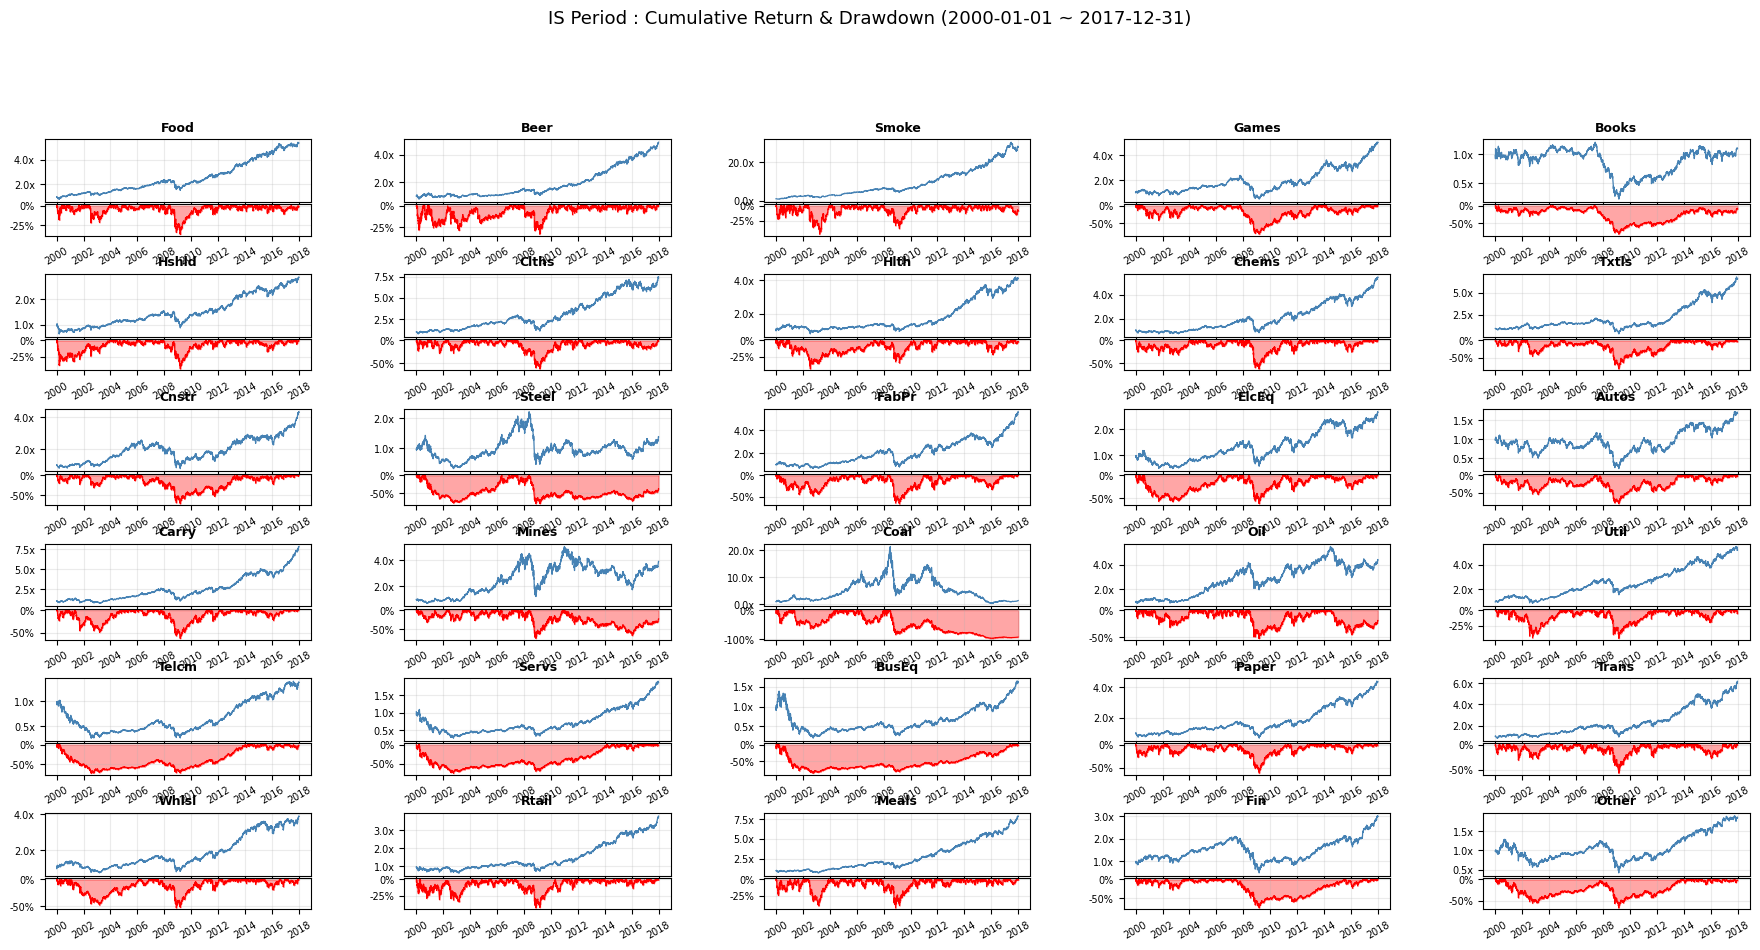

In [6]:
is_cum = (1 + is_df).cumprod()
is_dd  = (is_cum - is_cum.cummax()) / is_cum.cummax()

cols   = is_cum.columns.tolist()  # 10개 종목
N_COLS = 5
N_ROWS = 6  # 종목 행

fig = plt.figure(figsize=(22, 10))
outer = gridspec.GridSpec(N_ROWS, N_COLS, figure=fig, hspace=0.4, wspace=0.35)

for i, col in enumerate(cols):
    row, c = divmod(i, N_COLS)
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer[row, c],
        hspace=0.05, height_ratios=[2, 1]
    )

    ax_ret = fig.add_subplot(inner[0])
    ax_dd  = fig.add_subplot(inner[1], sharex=ax_ret)

    # 상단: 누적 수익률
    ax_ret.plot(is_cum.index, is_cum[col], color="steelblue", linewidth=0.9)
    ax_ret.set_title(col, fontsize=9, fontweight="bold")
    ax_ret.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.1f}x"))
    ax_ret.tick_params(axis="x", labelbottom=False)
    ax_ret.tick_params(labelsize=7)
    ax_ret.grid(True, alpha=0.25)

    # 하단: Drawdown
    ax_dd.fill_between(is_dd.index, is_dd[col], 0, alpha=0.35, color="red")
    ax_dd.plot(is_dd.index, is_dd[col], color="red", linewidth=0.8)
    ax_dd.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
    ax_dd.tick_params(labelsize=7)
    ax_dd.tick_params(axis="x", rotation=30)
    ax_dd.grid(True, alpha=0.25)

fig.suptitle(f"IS Period : Cumulative Return & Drawdown ({TRAIN_START} ~ {VAL_END})",
             fontsize=13, y=1.01)
plt.show()


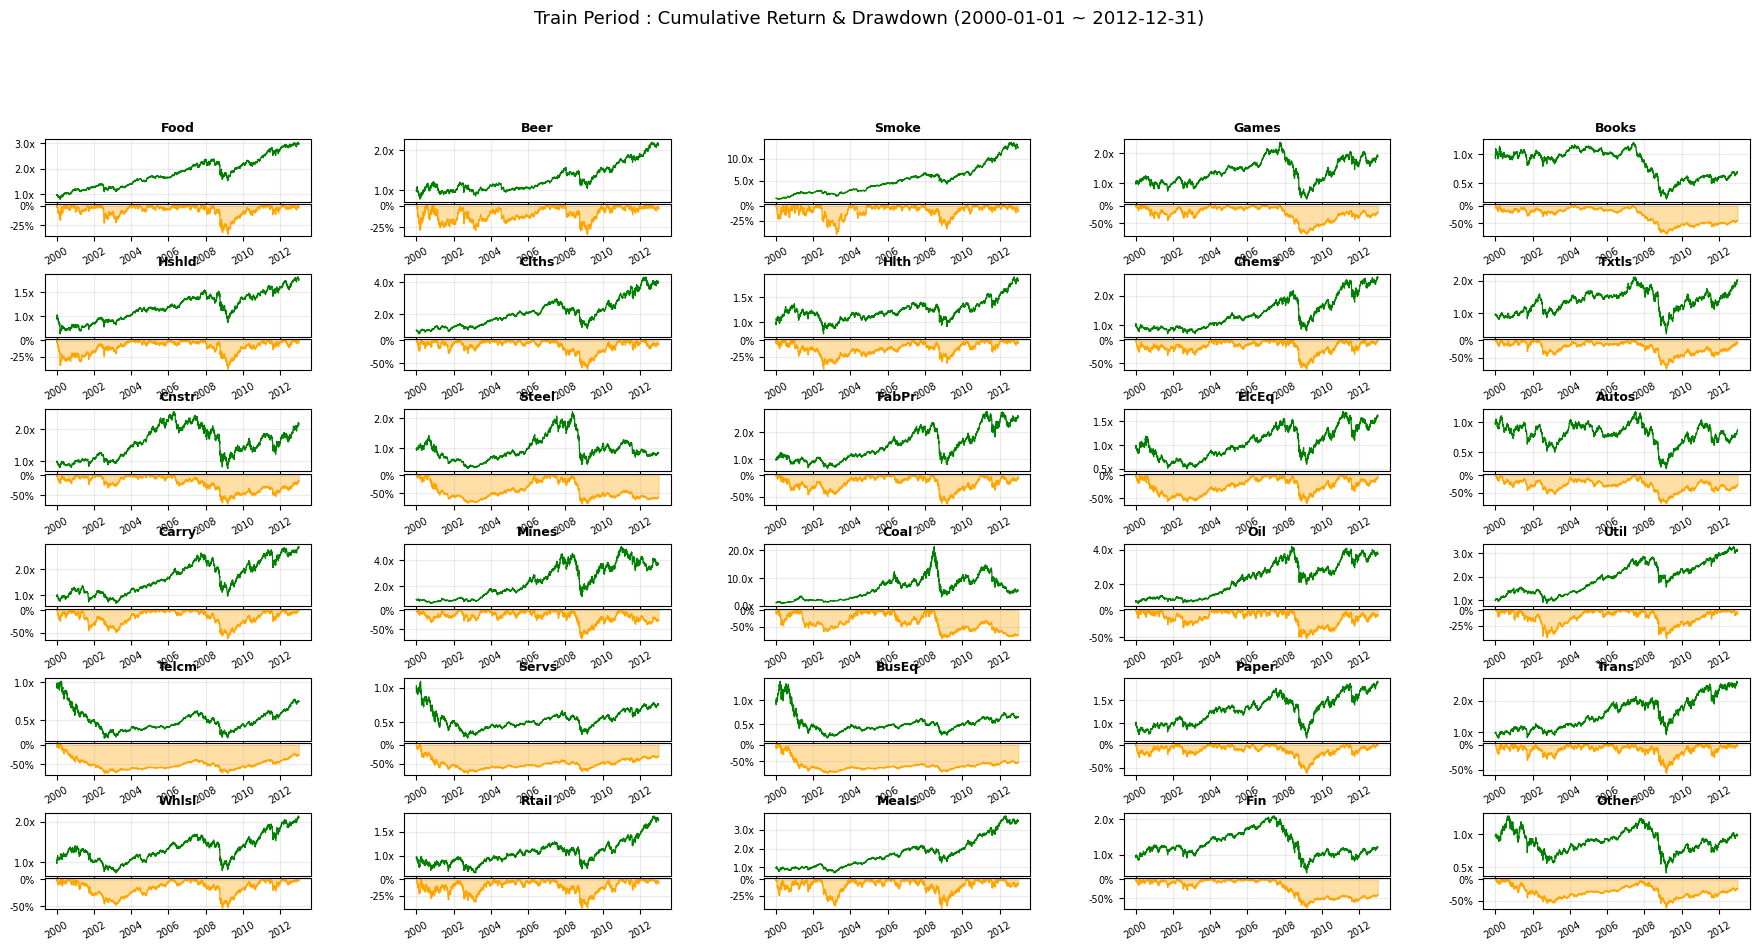

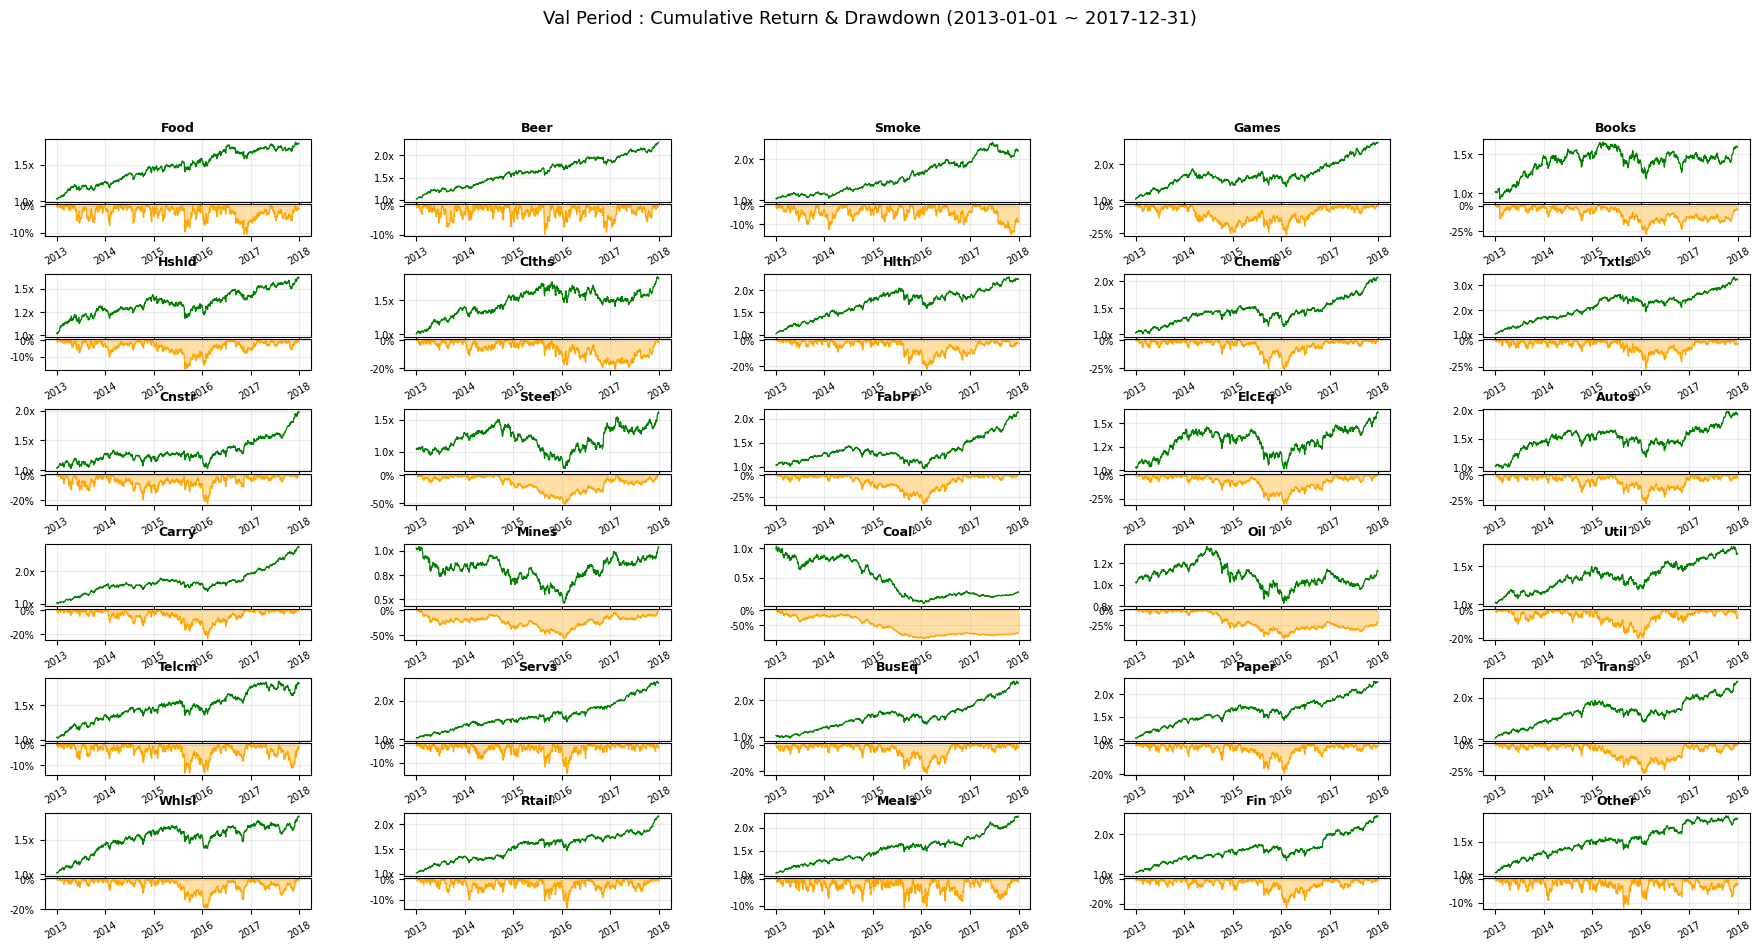

In [7]:
for period_df, period_name, p_start, p_end in [
    (train_df, "Train", TRAIN_START, TRAIN_END),
    (val_df,   "Val",   VAL_START,   VAL_END),
]:
    cum = (1 + period_df).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax()
    cols = cum.columns.tolist()

    fig = plt.figure(figsize=(22, 10))
    outer = gridspec.GridSpec(N_ROWS, N_COLS, figure=fig, hspace=0.4, wspace=0.35)

    for i, col in enumerate(cols):
        row, c = divmod(i, 5)
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer[row, c],
            hspace=0.05, height_ratios=[2, 1]
        )

        ax_ret = fig.add_subplot(inner[0])
        ax_dd  = fig.add_subplot(inner[1], sharex=ax_ret)

        # 상단: 누적 수익률
        ax_ret.plot(cum.index, cum[col], color="green", linewidth=0.9)
        ax_ret.set_title(col, fontsize=9, fontweight="bold")
        ax_ret.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.1f}x"))
        ax_ret.tick_params(axis="x", labelbottom=False)
        ax_ret.tick_params(labelsize=7)
        ax_ret.grid(True, alpha=0.25)

        # 하단: Drawdown
        ax_dd.fill_between(dd.index, dd[col], 0, alpha=0.35, color="orange")
        ax_dd.plot(dd.index, dd[col], color="orange", linewidth=0.8)
        ax_dd.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
        ax_dd.tick_params(labelsize=7)
        ax_dd.tick_params(axis="x", rotation=30)
        ax_dd.grid(True, alpha=0.25)

    fig.suptitle(f"{period_name} Period : Cumulative Return & Drawdown ({p_start} ~ {p_end})",
                 fontsize=13, y=1.01)
    plt.show()


In [9]:
def plot_multi_pnl(results_list, figsize=(14, 8), title="Cumulative PnL Comparison"):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize,
                                   gridspec_kw={"height_ratios": [3, 1]},
                                   sharex=True)
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))

    pv_store = []   # summary 계산용

    for (bt_results, label), color in zip(results_list, colors):
        pv = [1.0]
        for res in bt_results:
            w    = res["w_real"]
            base = pv[-1]
            pv.extend((base * (1 + w)).tolist())

        pv          = np.array(pv)
        running_max = np.maximum.accumulate(pv)
        drawdown    = (running_max - pv) / (running_max + 1e-10)
        total_ret   = pv[-1] - 1.0
        max_dd      = drawdown.max()
        calmar      = total_ret / (max_dd + 1e-10)

        full_label = f"{label}  R:{total_ret:.1%}  MDD:{max_dd:.1%}  Cal:{calmar:.2f}"
        ax1.plot(np.arange(len(pv)), pv, color=color, linewidth=1.5, label=full_label)
        ax2.plot(np.arange(len(pv)), -drawdown * 100, color=color, linewidth=1.0, alpha=0.7)
        pv_store.append((label, pv))

    ax1.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax1.set_ylabel("Portfolio Value")
    ax1.set_title(title)
    ax1.legend(loc="upper left", fontsize=8)
    ax1.grid(True, alpha=0.25)

    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("Trading Days (BT Period)")
    ax2.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
    ax2.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

    # ── Summary Table ──
    print(f"\n{'─'*75}")
    print(f"  {'Label':<35}  {'Ann.Ret':>8}  {'Ann.Vol':>8}  {'MDD':>8}  {'Calmar':>7}")
    print(f"{'─'*75}")
    for label, pv in pv_store:
        daily_rets  = np.diff(pv) / (pv[:-1] + 1e-10)
        n_days      = len(daily_rets)
        ann_ret     = (pv[-1] ** (252 / n_days)) - 1      # 기하 연율화
        ann_vol     = daily_rets.std() * np.sqrt(252)
        running_max = np.maximum.accumulate(pv)
        max_dd      = ((running_max - pv) / (running_max + 1e-10)).max()
        calmar      = ann_ret / (max_dd + 1e-10)
        print(f"  {label:<35}  {ann_ret:>8.2%}  {ann_vol:>8.2%}  {max_dd:>8.2%}  {calmar:>7.2f}")
    print(f"{'─'*75}")


DFL-MDD:  67%|▋| 40/60 [11:24:12<5:42:06, 1026.31s/it, LB=252, delta=50, lam=0.5
DFL-MDD:   0%|        | 0/30 [00:00<?, ?it/s, LB=252, delta=50, lam=0.3, n1=0.1]


############################################################
  DFL-MDD  |  delta=50, lam=0.3
############################################################

  Config: LOOKBACK=252, n1=0.1

── DFL-MDD Training (with Val Early Stopping + LR Scheduler) ──
  Epoch   1/300  train=0.024214  val=0.005817  lr=1.00e-04  *
  Epoch   5/300  train=0.017701  val=0.006813  lr=1.00e-04  (4/50)
  Epoch  10/300  train=0.016288  val=0.006979  lr=1.00e-04  (3/50)
  Epoch  15/300  train=0.017665  val=0.000313  lr=1.00e-04  *
  Epoch  20/300  train=0.014777  val=0.000061  lr=1.00e-04  *
  Epoch  25/300  train=0.021534  val=0.020259  lr=1.00e-04  (3/50)
  Epoch  30/300  train=0.017576  val=0.011688  lr=1.00e-04  (8/50)
  Epoch  35/300  train=0.016114  val=0.006974  lr=1.00e-04  (13/50)
  Epoch  40/300  train=0.014861  val=0.013369  lr=1.00e-04  (18/50)
  Epoch  45/300  train=0.015443  val=0.011941  lr=5.00e-05  (23/50)


/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/diffcp/cone_program.py:522: UserWarning: Solved/Inaccurate.
  warnings.warn("Solved/Inaccurate.")


  Epoch  50/300  train=0.012351  val=0.010776  lr=5.00e-05  (28/50)
  Epoch  55/300  train=0.011643  val=0.009028  lr=5.00e-05  (33/50)
  Epoch  60/300  train=0.010717  val=0.006702  lr=5.00e-05  (38/50)
  Epoch  65/300  train=0.008669  val=0.008756  lr=2.50e-05  (43/50)
  Epoch  70/300  train=0.007751  val=0.007957  lr=2.50e-05  (48/50)
  Early stopping at epoch 72  (best val=-0.001318)

── Backtest : DFL-MDD ──
 Win    R_real    Sharpe    MDD(%)  Top-3 weights
---------------------------------------------------------------------------


    1    0.0039    0.0181   1.6501%  {'Beer': 0.877, 'Steel': 0.123, 'Hshld': 0.0}
    2   -0.0952   -0.4135  12.0716%  {'Oil': 0.776, 'Hshld': 0.224, 'Hlth': 0.0}
    3   -0.0033   -0.0155  13.5214%  {'Hshld': 0.799, 'Hlth': 0.201, 'Beer': 0.0}
    4   -0.0761   -0.3555  17.9655%  {'Beer': 0.751, 'Hshld': 0.249, 'Hlth': 0.0}
    5    0.0365    0.1593  18.0453%  {'Oil': 0.619, 'Beer': 0.381, 'Hlth': 0.0}
    6    0.0440    0.1726  18.0453%  {'Beer': 0.96, 'Carry': 0.04, 'Steel': 0.0}
    7    0.0221    0.0965  18.0453%  {'Hshld': 0.791, 'Beer': 0.209, 'Trans': 0.0}
    8   -0.0112   -0.0461  18.0453%  {'Beer': 0.874, 'Steel': 0.084, 'FabPr': 0.043}
    9   -0.0034   -0.0134  18.0453%  {'Beer': 0.922, 'Trans': 0.078, 'Oil': 0.0}
   10   -0.0056   -0.0263  18.0453%  {'Beer': 0.552, 'Hshld': 0.424, 'Hlth': 0.024}
   11    0.0430    0.1984  18.0453%  {'Beer': 0.463, 'Hshld': 0.448, 'Trans': 0.089}
   12   -0.0932   -0.3705  19.1666%  {'Beer': 0.834, 'Steel': 0.141, 'Hshld': 0.016}
   13   

...

   70    0.0033    0.0118  31.2994%  {'Food': 0.977, 'Autos': 0.023, 'Telcm': 0.0}
   71    0.0337    0.1165  31.2994%  {'Food': 1.0, 'Rtail': 0.0, 'Chems': 0.0}
   72    0.0290    0.1070  31.2994%  {'Food': 0.898, 'Util': 0.102, 'Telcm': 0.0}
   73   -0.0121   -0.0421  31.2994%  {'Food': 1.0, 'Oil': 0.0, 'Meals': 0.0}
   74    0.0238    0.0935  31.2994%  {'Food': 0.696, 'Util': 0.304, 'Chems': 0.0}
   75    0.0261    0.1046  31.2994%  {'Food': 0.646, 'Util': 0.354, 'Telcm': 0.0}
   76    0.0172    0.0607  31.2994%  {'Food': 1.0, 'Telcm': 0.0, 'Oil': 0.0}
   77    0.0058    0.0230  31.2994%  {'Food': 0.77, 'Util': 0.23, 'Oil': 0.0}
   78   -0.0233   -0.0885  31.2994%  {'Food': 0.931, 'Util': 0.069, 'Telcm': 0.0}
   79    0.0548    0.1752  31.2994%  {'Util': 1.0, 'Food': 0.0, 'Telcm': 0.0}
   80    0.0487    0.2076  31.2994%  {'Food': 0.595, 'Util': 0.405, 'Oil': -0.0}
   81   -0.0093   -0.0348  31.2994%  {'Food': 0.978, 'Util': 0.022, 'Telcm': 0.0}
   82   -0.0327   -0.1075  31.2994%  

    1    0.0627    0.2259   3.4085%  {'Hlth': 1.0, 'Autos': 0.0, 'Books': 0.0}
    2   -0.0680   -0.2672  10.7784%  {'Food': 1.0, 'Hlth': 0.0, 'Carry': 0.0}
    3   -0.0302   -0.1176  13.9647%  {'Food': 1.0, 'Carry': 0.0, 'Telcm': 0.0}
    4   -0.0298   -0.1153  15.2971%  {'Food': 1.0, 'Carry': 0.0, 'Meals': 0.0}
    5    0.0209    0.0809  15.6020%  {'Food': 1.0, 'Util': 0.0, 'Meals': 0.0}
    6    0.0435    0.1689  15.6020%  {'Food': 1.0, 'Autos': 0.0, 'Meals': 0.0}
    7    0.0087    0.0334  15.6020%  {'Meals': 1.0, 'Carry': 0.0, 'Hlth': 0.0}
    8    0.0397    0.1444  15.6020%  {'Hlth': 1.0, 'Food': 0.0, 'Whlsl': 0.0}
    9    0.0220    0.0803  15.6020%  {'Hlth': 1.0, 'Food': 0.0, 'Carry': 0.0}
   10    0.0237    0.0929  15.6020%  {'Food': 1.0, 'Hlth': 0.0, 'Carry': 0.0}
   11    0.0049    0.0190  15.6020%  {'Food': 1.0, 'Carry': 0.0, 'Meals': 0.0}
   12   -0.0773   -0.2802  15.8959%  {'Hlth': 1.0, 'Carry': 0.0, 'Food': 0.0}
   13    0.0718    0.2776  15.8959%  {'Food': 1.0, 'Hlth':

   70   -0.0108   -0.0355  31.1623%  {'Hlth': 1.0, 'Meals': 0.0, 'Books': 0.0}
   71    0.0337    0.1165  31.1623%  {'Food': 1.0, 'Hlth': 0.0, 'Autos': 0.0}
   72    0.0299    0.1042  31.1623%  {'Food': 1.0, 'Util': 0.0, 'Chems': 0.0}


Backtesting: 100%|██████████| 95/95 [00:00<00:00, 353.36it/s]
DFL-MDD:  33%|▎| 10/30 [2:45:45<4:58:46, 896.30s/it, LB=504, delta=50, lam=0.3, 

   73   -0.0121   -0.0421  31.1623%  {'Food': 1.0, 'Carry': 0.0, 'Books': 0.0}
   74    0.0373    0.1231  31.1623%  {'Hlth': 1.0, 'Food': 0.0, 'Util': 0.0}
   75   -0.0165   -0.0552  31.1623%  {'Hlth': 0.995, 'Meals': 0.005, 'Food': 0.0}
   76    0.0172    0.0607  31.1623%  {'Food': 1.0, 'Books': 0.0, 'Fin': 0.0}
   77    0.0508    0.1484  31.1623%  {'Carry': 1.0, 'Food': 0.0, 'Hlth': 0.0}
   78   -0.0304   -0.0991  31.1623%  {'Meals': 1.0, 'Hlth': 0.0, 'Carry': 0.0}
   79    0.0491    0.1816  31.1623%  {'Food': 1.0, 'Telcm': 0.0, 'Util': 0.0}
   80    0.0592    0.2122  31.1623%  {'Hlth': 1.0, 'Fin': 0.0, 'Food': 0.0}
   81   -0.0098   -0.0353  31.1623%  {'Hlth': 1.0, 'Autos': 0.0, 'Meals': 0.0}
   82   -0.0313   -0.1176  31.1623%  {'Food': 1.0, 'Carry': 0.0, 'Meals': 0.0}
   83   -0.0192   -0.0733  31.1623%  {'Food': 1.0, 'Meals': 0.0, 'Whlsl': 0.0}
   84   -0.0458   -0.1629  31.1623%  {'Meals': 1.0, 'Hlth': 0.0, 'Fin': 0.0}
   85    0.0675    0.2546  31.1623%  {'Hlth': 1.0, 'Autos': 

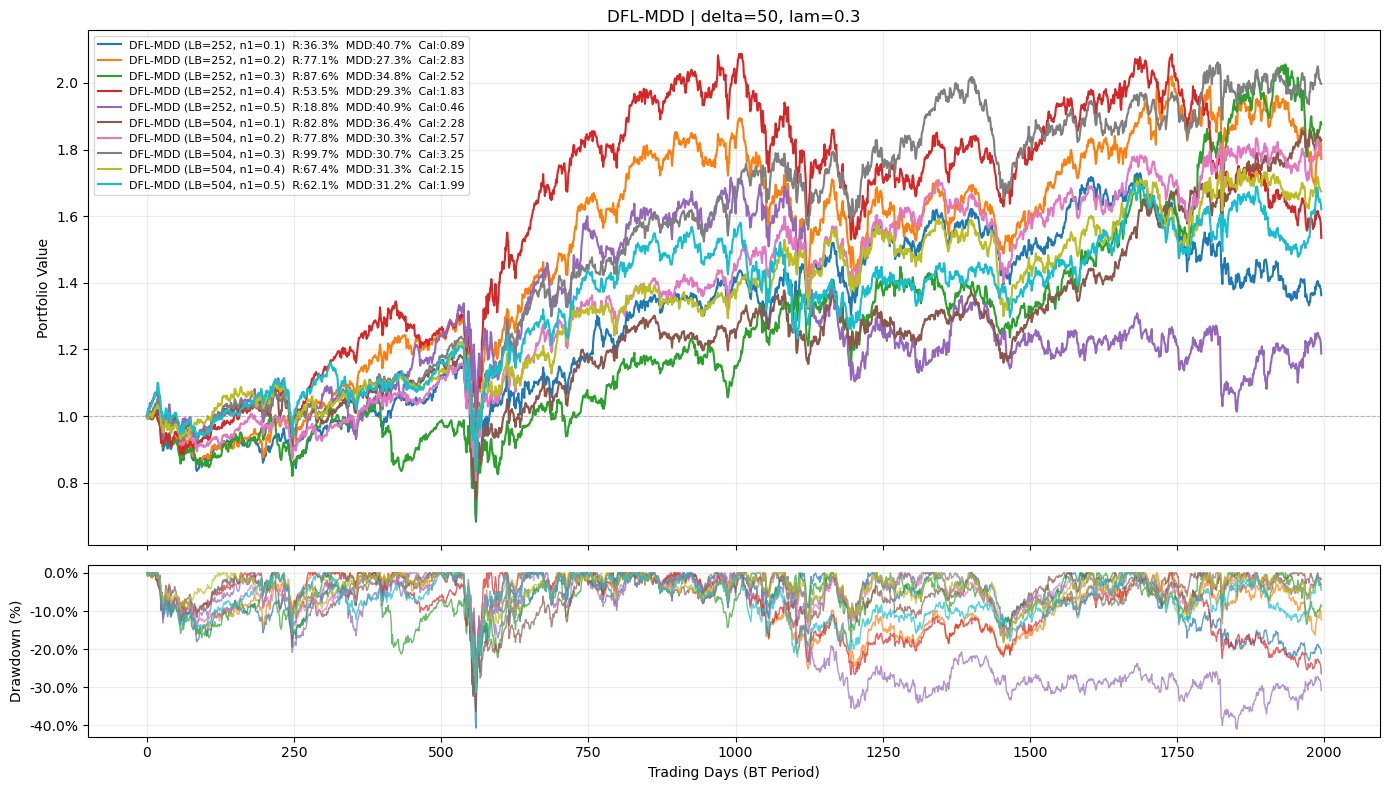

DFL-MDD:  33%|▎| 10/30 [2:45:45<4:58:46, 896.30s/it, LB=252, delta=50, lam=0.5, 


───────────────────────────────────────────────────────────────────────────
  Label                                 Ann.Ret   Ann.Vol       MDD   Calmar
───────────────────────────────────────────────────────────────────────────
  DFL-MDD (LB=252, n1=0.1)                3.99%    21.35%    40.70%     0.10
  DFL-MDD (LB=252, n1=0.2)                7.49%    19.14%    27.28%     0.27
  DFL-MDD (LB=252, n1=0.3)                8.27%    20.36%    34.76%     0.24
  DFL-MDD (LB=252, n1=0.4)                5.56%    19.49%    29.26%     0.19
  DFL-MDD (LB=252, n1=0.5)                2.19%    22.22%    40.91%     0.05
  DFL-MDD (LB=504, n1=0.1)                7.92%    17.99%    36.40%     0.22
  DFL-MDD (LB=504, n1=0.2)                7.54%    16.83%    30.31%     0.25
  DFL-MDD (LB=504, n1=0.3)                9.13%    17.23%    30.72%     0.30
  DFL-MDD (LB=504, n1=0.4)                6.73%    17.20%    31.30%     0.21
  DFL-MDD (LB=504, n1=0.5)                6.29%    18.45%    31.16%     0.20


    1   -0.0281   -0.1169   4.0000%  {'Util': 1.0, 'Hshld': 0.0, 'Chems': 0.0}
    2   -0.0560   -0.3151   9.4072%  {'Hshld': 0.604, 'Util': 0.396, 'Coal': 0.0}
    3    0.0182    0.0971   9.4072%  {'Util': 0.527, 'Hshld': 0.473, 'Meals': 0.0}
    4   -0.0273   -0.1418   9.4072%  {'Hshld': 0.563, 'Util': 0.437, 'Chems': -0.0}
    5   -0.0091   -0.0359  12.1616%  {'Util': 1.0, 'Hshld': 0.0, 'Meals': 0.0}
    6    0.0346    0.1710  12.1616%  {'Hshld': 0.668, 'Util': 0.224, 'Chems': 0.108}
    7    0.0173    0.0780  12.1616%  {'Hshld': 0.783, 'Util': 0.217, 'Autos': 0.0}
    8    0.0281    0.1181  12.1616%  {'Hshld': 0.832, 'Chems': 0.168, 'Util': 0.0}
    9   -0.0016   -0.0080  12.1616%  {'Util': 0.611, 'Hshld': 0.389, 'Coal': 0.0}
   10   -0.0059   -0.0239  12.1616%  {'Hshld': 0.899, 'Util': 0.077, 'Chems': 0.024}
   11    0.0515    0.1820  12.1616%  {'Hshld': 1.0, 'Util': 0.0, 'Chems': 0.0}
   12   -0.0478   -0.2205  12.1616%  {'Hshld': 0.559, 'Util': 0.441, 'Chems': 0.0}
   13    0.07

   64    0.0171    0.0583  32.5348%  {'Hshld': 0.586, 'Util': 0.414, 'Meals': 0.0}
   65   -0.0492   -0.1620  32.5348%  {'Hshld': 0.793, 'Util': 0.207, 'Chems': 0.0}
   66    0.0400    0.1243  32.5348%  {'Hshld': 1.0, 'Util': 0.0, 'Coal': 0.0}


Backtesting: 100%|██████████| 95/95 [00:00<00:00, 316.00it/s]
DFL-MDD:  37%|▎| 11/30 [3:00:30<4:42:44, 892.87s/it, LB=252, delta=50, lam=0.5, 

...

   78   -0.0233   -0.0852  31.1623%  {'Food': 1.0, 'Carry': 0.0, 'Chems': 0.0}
   79    0.0491    0.1816  31.1623%  {'Food': 1.0, 'Telcm': 0.0, 'Util': 0.0}
   80    0.0472    0.1742  31.1623%  {'Food': 1.0, 'Hlth': 0.0, 'Fin': 0.0}
   81   -0.0109   -0.0404  31.1623%  {'Food': 1.0, 'Books': 0.0, 'Coal': 0.0}
   82   -0.0072   -0.0248  31.1623%  {'Meals': 1.0, 'Food': 0.0, 'Carry': 0.0}
   83    0.3349    0.5332  31.1623%  {'Autos': 1.0, 'Food': 0.0, 'Steel': 0.0}
   84   -0.0449   -0.1719  31.1623%  {'Food': 1.0, 'Fin': 0.0, 'Carry': 0.0}
   85    0.0012    0.0046  31.1623%  {'Food': 1.0, 'Carry': 0.0, 'Books': 0.0}
   86   -0.3917   -0.6279  42.3218%  {'Autos': 1.0, 'Hlth': 0.0, 'Food': 0.0}
   87   -0.0577   -0.2183  45.6498%  {'Food': 1.0, 'Carry': 0.0, 'Whlsl': 0.0}
   88    0.0445    0.1657  45.6498%  {'Food': 1.0, 'Carry': 0.0, 'Meals': 0.0}
   89    0.0098    0.0360  45.6498%  {'Food': 1.0, 'Carry': 0.0, 'Books': 0.0}
   90   -0.0100   -0.0366  45.6498%  {'Food': 1.0, 'Carry': 

    1    0.0247    0.0957   1.2986%  {'Food': 1.0, 'Autos': 0.0, 'Books': 0.0}
    2   -0.0560   -0.2623   7.6446%  {'Food': 0.725, 'Books': 0.275, 'Txtls': 0.0}
    3   -0.0302   -0.1176  10.5653%  {'Food': 1.0, 'Books': 0.0, 'Autos': 0.0}
    4   -0.0298   -0.1153  11.9503%  {'Food': 1.0, 'Books': 0.0, 'Trans': 0.0}
    5    0.0209    0.0809  12.2673%  {'Food': 1.0, 'Books': 0.0, 'Whlsl': 0.0}
    6    0.0435    0.1689  12.2673%  {'Food': 1.0, 'Autos': 0.0, 'Books': 0.0}
    7    0.0201    0.0788  12.2673%  {'Food': 1.0, 'Whlsl': 0.0, 'Autos': 0.0}
    8    0.0044    0.0172  12.2673%  {'Food': 1.0, 'Books': 0.0, 'Autos': 0.0}
    9   -0.0052   -0.0202  12.2673%  {'Food': 1.0, 'Books': 0.0, 'Trans': 0.0}
   10    0.0178    0.0746  12.2673%  {'Food': 0.915, 'Autos': 0.085, 'Books': 0.0}
   11    0.0049    0.0190  12.2673%  {'Food': 1.0, 'Books': 0.0, 'Autos': 0.0}
   12   -0.0949   -0.3711  13.6644%  {'Food': 1.0, 'Autos': 0.0, 'Books': 0.0}
   13    0.0718    0.2776  13.6644%  {'Food'

   63    0.0345    0.1203  39.6156%  {'Food': 1.0, 'Autos': 0.0, 'Whlsl': 0.0}
   64    0.0265    0.0927  39.6156%  {'Food': 1.0, 'Autos': 0.0, 'Books': 0.0}
   65   -0.0320   -0.1121  39.6156%  {'Food': 1.0, 'Autos': 0.0, 'Whlsl': 0.0}


Backtesting: 100%|██████████| 95/95 [00:00<00:00, 327.42it/s]
DFL-MDD:  67%|▋| 20/30 [5:15:39<3:10:23, 1142.38s/it, LB=504, delta=50, lam=0.5,

   66    0.0072    0.0277  39.6156%  {'Food': 0.645, 'Books': 0.355, 'Autos': 0.0}
   67    0.0458    0.1161  39.6156%  {'Books': 1.0, 'Food': 0.0, 'Autos': 0.0}
   68    0.0091    0.0274  39.6156%  {'Books': 0.621, 'Food': 0.21, 'Autos': 0.169}
   69   -0.0505   -0.1769  39.6156%  {'Food': 1.0, 'Books': 0.0, 'Trans': 0.0}
   70    0.0069    0.0242  39.6156%  {'Food': 1.0, 'Autos': 0.0, 'Whlsl': 0.0}
   71    0.0337    0.1165  39.6156%  {'Food': 1.0, 'Books': 0.0, 'Autos': 0.0}
   72    0.0299    0.1042  39.6156%  {'Food': 1.0, 'Books': 0.0, 'Autos': 0.0}
   73   -0.0602   -0.1569  39.6156%  {'Books': 0.531, 'Autos': 0.34, 'Food': 0.129}
   74    0.0067    0.0200  39.6156%  {'Food': 0.637, 'Autos': 0.363, 'Txtls': 0.0}
   75    0.0131    0.0469  39.6156%  {'Food': 0.908, 'Autos': 0.092, 'Trans': -0.0}
   76    0.0172    0.0607  39.6156%  {'Food': 1.0, 'Autos': 0.0, 'Books': 0.0}
   77   -0.0032   -0.0114  39.6156%  {'Food': 1.0, 'Autos': 0.0, 'Whlsl': 0.0}
   78   -0.0233   -0.0852  39

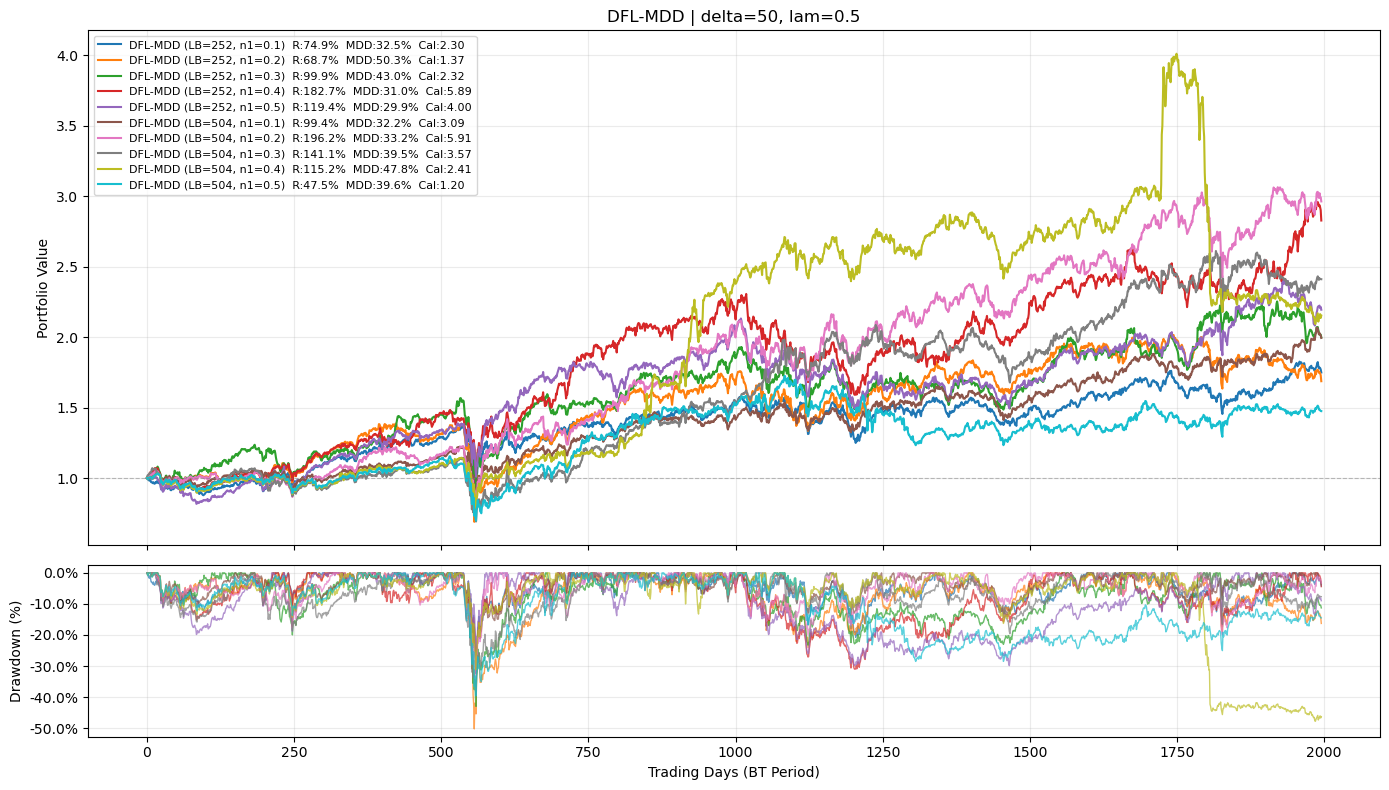

DFL-MDD:  67%|▋| 20/30 [5:15:39<3:10:23, 1142.38s/it, LB=252, delta=50, lam=0.7,


───────────────────────────────────────────────────────────────────────────
  Label                                 Ann.Ret   Ann.Vol       MDD   Calmar
───────────────────────────────────────────────────────────────────────────
  DFL-MDD (LB=252, n1=0.1)                7.32%    19.01%    32.53%     0.22
  DFL-MDD (LB=252, n1=0.2)                6.83%    23.68%    50.27%     0.14
  DFL-MDD (LB=252, n1=0.3)                9.14%    22.27%    43.00%     0.21
  DFL-MDD (LB=252, n1=0.4)               14.03%    21.70%    31.01%     0.45
  DFL-MDD (LB=252, n1=0.5)               10.44%    20.43%    29.88%     0.35
  DFL-MDD (LB=504, n1=0.1)                9.11%    17.19%    32.17%     0.28
  DFL-MDD (LB=504, n1=0.2)               14.70%    20.87%    33.20%     0.44
  DFL-MDD (LB=504, n1=0.3)               11.76%    20.98%    39.50%     0.30
  DFL-MDD (LB=504, n1=0.4)               10.17%    22.30%    47.81%     0.21
  DFL-MDD (LB=504, n1=0.5)                5.03%    21.00%    39.62%     0.13


    1    0.0905    0.3597   1.3948%  {'Servs': 1.0, 'Smoke': 0.0, 'Meals': 0.0}
    2   -0.0507   -0.1872   8.4771%  {'Smoke': 1.0, 'Servs': 0.0, 'Meals': 0.0}
    3   -0.0419   -0.1543  10.3184%  {'Servs': 0.987, 'Smoke': 0.013, 'Meals': 0.0}
    4   -0.1144   -0.4659  19.9198%  {'Smoke': 0.743, 'Servs': 0.257, 'Meals': -0.0}
    5   -0.0038   -0.0120  20.3927%  {'Smoke': 0.913, 'Servs': 0.087, 'Games': 0.0}
    6    0.0234    0.0864  20.3927%  {'Smoke': 0.717, 'Servs': 0.283, 'Games': 0.0}
    7    0.0476    0.1577  20.3927%  {'Smoke': 0.845, 'Servs': 0.155, 'Games': -0.0}
    8   -0.0262   -0.0862  20.3927%  {'Smoke': 0.856, 'Servs': 0.144, 'Meals': 0.0}
    9    0.0278    0.1102  20.3927%  {'Smoke': 0.586, 'Servs': 0.414, 'Meals': -0.0}
   10    0.0869    0.2534  20.3927%  {'Smoke': 0.956, 'Servs': 0.044, 'BusEq': 0.0}
   11   -0.0428   -0.1559  20.3927%  {'Smoke': 0.634, 'Games': 0.366, 'Servs': 0.0}
   12   -0.1727   -0.4865  28.9385%  {'Smoke': 0.964, 'Servs': 0.036, 'Meals': -0

   71    0.0388    0.1517  30.8062%  {'Smoke': 0.676, 'Games': 0.324, 'Servs': 0.0}
   72    0.0234    0.1040  30.8062%  {'Smoke': 0.594, 'Servs': 0.303, 'Trans': 0.103}


Backtesting: 100%|██████████| 95/95 [00:00<00:00, 348.91it/s]
DFL-MDD:  70%|▋| 21/30 [5:33:19<2:47:37, 1117.53s/it, LB=252, delta=50, lam=0.7,

...

   75    0.0285    0.0909  43.2736%  {'Whlsl': 1.0, 'Food': 0.0, 'Hlth': 0.0}
   76    0.0043    0.0131  43.2736%  {'Fin': 1.0, 'Food': 0.0, 'Whlsl': 0.0}
   77   -0.0067   -0.0219  43.2736%  {'Whlsl': 1.0, 'Food': 0.0, 'Books': 0.0}
   78   -0.0233   -0.0852  43.2736%  {'Food': 1.0, 'Whlsl': 0.0, 'Books': 0.0}
   79    0.0503    0.2069  43.2736%  {'Food': 0.794, 'Util': 0.206, 'Fin': 0.0}
   80    0.0472    0.1742  43.2736%  {'Food': 1.0, 'Whlsl': 0.0, 'Fin': 0.0}
   81   -0.0109   -0.0404  43.2736%  {'Food': 1.0, 'Whlsl': 0.0, 'Fin': 0.0}
   82   -0.0273   -0.1100  43.2736%  {'Food': 0.905, 'Whlsl': 0.095, 'Fin': 0.0}
   83    0.1017    0.3691  43.2736%  {'Whlsl': 1.0, 'Coal': 0.0, 'Food': 0.0}
   84   -0.0844   -0.3036  43.2736%  {'Whlsl': 1.0, 'Food': 0.0, 'Autos': 0.0}
   85    0.0413    0.1490  43.2736%  {'Whlsl': 1.0, 'Coal': 0.0, 'Trans': 0.0}
   86    0.0946    0.3620  43.2736%  {'Food': 1.0, 'Whlsl': 0.0, 'BusEq': 0.0}
   87   -0.0577   -0.2183  43.2736%  {'Food': 1.0, 'Whlsl

    1    0.0627    0.2259   3.4085%  {'Hlth': 1.0, 'Food': 0.0, 'Chems': 0.0}
    2   -0.0371   -0.1637  11.2986%  {'Hlth': 0.737, 'Chems': 0.263, 'Food': 0.0}
    3   -0.0388   -0.1410  11.8018%  {'Hlth': 1.0, 'Autos': 0.0, 'Chems': 0.0}
    4   -0.0298   -0.1153  13.2661%  {'Food': 1.0, 'Hlth': 0.0, 'Whlsl': 0.0}
    5    0.0209    0.0809  13.5783%  {'Food': 1.0, 'Hlth': 0.0, 'Chems': 0.0}
    6    0.0076    0.0274  13.5783%  {'Hlth': 1.0, 'Food': 0.0, 'Autos': 0.0}
    7    0.0572    0.2089  13.5783%  {'Hlth': 1.0, 'Food': 0.0, 'Fin': 0.0}
    8    0.0375    0.1448  13.5783%  {'Hlth': 0.919, 'Chems': 0.081, 'Food': 0.0}
    9    0.0220    0.0803  13.5783%  {'Hlth': 1.0, 'Autos': 0.0, 'Food': 0.0}
   10    0.0237    0.0929  13.5783%  {'Food': 1.0, 'Books': 0.0, 'Carry': 0.0}
   11    0.0049    0.0190  13.5783%  {'Food': 1.0, 'Hlth': 0.0, 'Books': 0.0}
   12   -0.0949   -0.3711  13.5783%  {'Food': 1.0, 'Hlth': 0.0, 'Chems': 0.0}
   13    0.0718    0.2776  13.5783%  {'Food': 1.0, 'Util

   72    0.0328    0.1249  28.1046%  {'Food': 0.825, 'Books': 0.175, 'Telcm': 0.0}
   73   -0.0121   -0.0421  28.1046%  {'Food': 1.0, 'Hlth': 0.0, 'Whlsl': 0.0}
   74    0.0075    0.0262  28.1046%  {'Food': 0.989, 'Hlth': 0.011, 'Chems': 0.0}


Backtesting: 100%|██████████| 95/95 [00:00<00:00, 361.93it/s]
DFL-MDD: 100%|█| 30/30 [7:31:06<00:00, 775.84s/it, LB=504, delta=50, lam=0.7, n1

   75   -0.0165   -0.0550  28.1046%  {'Hlth': 1.0, 'Chems': 0.0, 'Fin': 0.0}
   76    0.0172    0.0607  28.1046%  {'Food': 1.0, 'Hlth': 0.0, 'Chems': 0.0}
   77   -0.0032   -0.0114  28.1046%  {'Food': 1.0, 'Hlth': 0.0, 'Chems': 0.0}
   78   -0.0233   -0.0852  28.1046%  {'Food': 1.0, 'Chems': 0.0, 'Hlth': 0.0}
   79    0.0491    0.1816  28.1046%  {'Food': 1.0, 'Hlth': 0.0, 'Chems': 0.0}
   80    0.0592    0.2122  28.1046%  {'Hlth': 1.0, 'Chems': 0.0, 'Fin': 0.0}
   81    0.0044    0.0175  28.1046%  {'Hlth': 0.803, 'Chems': 0.197, 'Food': 0.0}
   82   -0.0265   -0.1275  28.1046%  {'Food': 0.601, 'Hlth': 0.264, 'Chems': 0.136}
   83   -0.0059   -0.0221  28.1046%  {'Hlth': 1.0, 'Food': 0.0, 'Autos': 0.0}
   84   -0.0434   -0.1633  28.1046%  {'Hlth': 1.0, 'Chems': 0.0, 'Autos': 0.0}
   85    0.0598    0.2477  28.1046%  {'Hlth': 0.885, 'Food': 0.115, 'Chems': 0.0}
   86   -0.0026   -0.0098  28.1046%  {'Hlth': 1.0, 'Food': 0.0, 'Autos': 0.0}
   87   -0.1308   -0.4921  28.1046%  {'Hlth': 1.0, 

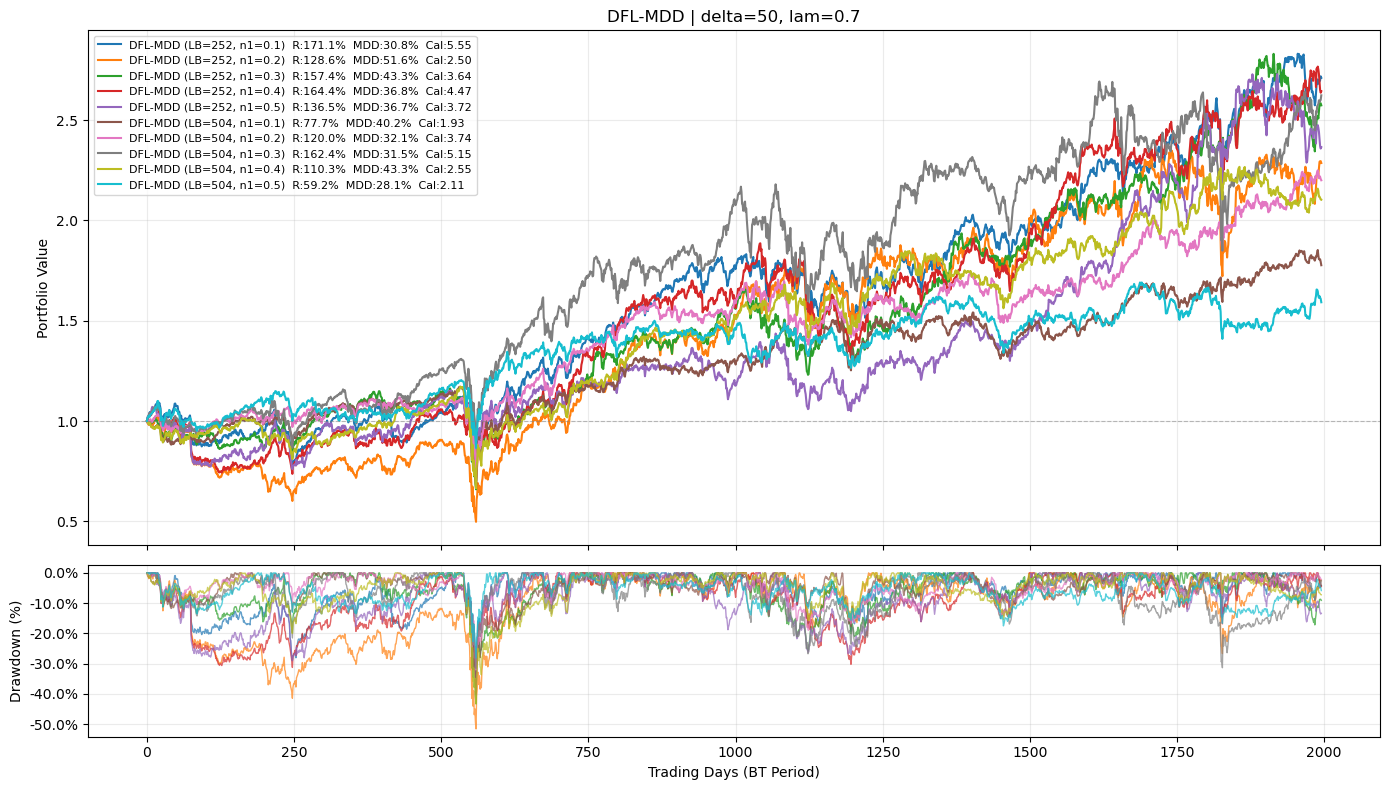

DFL-MDD: 100%|█| 30/30 [7:31:06<00:00, 902.22s/it, LB=504, delta=50, lam=0.7, n1


───────────────────────────────────────────────────────────────────────────
  Label                                 Ann.Ret   Ann.Vol       MDD   Calmar
───────────────────────────────────────────────────────────────────────────
  DFL-MDD (LB=252, n1=0.1)               13.43%    21.91%    30.81%     0.44
  DFL-MDD (LB=252, n1=0.2)               11.01%    27.31%    51.55%     0.21
  DFL-MDD (LB=252, n1=0.3)               12.68%    24.23%    43.25%     0.29
  DFL-MDD (LB=252, n1=0.4)               13.07%    23.40%    36.76%     0.36
  DFL-MDD (LB=252, n1=0.5)               11.49%    23.85%    36.75%     0.31
  DFL-MDD (LB=504, n1=0.1)                7.53%    18.85%    40.23%     0.19
  DFL-MDD (LB=504, n1=0.2)               10.47%    18.26%    32.09%     0.33
  DFL-MDD (LB=504, n1=0.3)               12.96%    24.24%    31.53%     0.41
  DFL-MDD (LB=504, n1=0.4)                9.85%    21.00%    43.27%     0.23
  DFL-MDD (LB=504, n1=0.5)                6.05%    17.65%    28.10%     0.22


In [31]:
import importlib
from tqdm.auto import tqdm

import dfl_mdd
importlib.reload(dfl_mdd)
from dfl_mdd import (
    PredictionModel, build_optimization_layer, solve_portfolio,
    compute_cumulative_path, compute_realized_path, compute_return,
    compute_max_drawdown, dfl_loss, forward_pass,
    train_dfl_mdd, backtest_dfl_mdd, plot_pnl,
)

total = len(DELTA_LIST) * len(LAM_LIST) * len(configs)
pbar  = tqdm(total=total, desc="DFL-MDD", ncols=80)

for delta_val in DELTA_LIST:
    for lam_val in LAM_LIST:
        print(f"\n{'#'*60}")
        print(f"  DFL-MDD  |  delta={delta_val}, lam={lam_val}")
        print(f"{'#'*60}")

        all_results_dfl_mdd = []

        for cfg in configs:
            LOOKBACK = cfg["LOOKBACK"]
            n1       = cfg["n1"]

            print(f"\n{'='*60}")
            print(f"  Config: LOOKBACK={LOOKBACK}, n1={n1}")
            print(f"{'='*60}")

            pbar.set_postfix(delta=delta_val, lam=lam_val, LB=LOOKBACK, n1=n1)

            INPUT_DIM = LOOKBACK * N_STOCKS

            train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                         start=LOOKBACK, end=N_TRAIN)
            val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                         start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
            val_samples   = val_samples[::HORIZON]
            rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                         start=BT_START_IDX, end=BT_START_IDX + N_BT)
            rebal_samples = rebal_samples[::HORIZON]

            torch.manual_seed(42)

            pred_model = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
            opt_layer  = build_optimization_layer(N, M, gamma, delta=delta_val)

            train_dfl_mdd(
                pred_model, opt_layer, train_samples, val_samples,
                epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
                n1=n1, C=C, d=d, x_min=x_min, x_max=x_max, lam=lam_val,
                is_mean=is_mean, is_std=is_std, delta=delta_val,
                patience=PATIENCE, lr_patience=20, lr_factor=0.5,
            )

            bt_dfl_mdd = backtest_dfl_mdd(
                pred_model=pred_model, opt_layer=opt_layer,
                rebal_samples=rebal_samples, N=HORIZON, d=d, C=C,
                n1=n1, x_min=x_min, x_max=x_max,
                delta=delta_val, is_mean=is_mean, is_std=is_std,
                stock_names=stock_names,
            )
            all_results_dfl_mdd.append((bt_dfl_mdd, f"DFL-MDD (LB={LOOKBACK}, n1={n1})"))
            pbar.update(1)
            pbar.refresh()

        plot_multi_pnl(all_results_dfl_mdd, title=f"DFL-MDD | delta={delta_val}, lam={lam_val}")

pbar.close()


PTO-MDD:   0%|                 | 0/10 [00:00<?, ?it/s, LB=252, delta=20, n1=0.1]


── PTO-MDD Training (MSE + Val Early Stopping) ──
  Epoch   1/300  train=0.003949  val=0.001294  *
  Epoch   5/300  train=0.000333  val=0.000202  *
  Epoch  10/300  train=0.000300  val=0.000146  *
  Epoch  15/300  train=0.000300  val=0.000136  *
  Epoch  20/300  train=0.000302  val=0.000134  *
  Epoch  25/300  train=0.000301  val=0.000134  (1/50)
  Epoch  30/300  train=0.000301  val=0.000134  *
  Epoch  35/300  train=0.000301  val=0.000134  (2/50)
  Epoch  40/300  train=0.000300  val=0.000134  (7/50)
  Epoch  45/300  train=0.000302  val=0.000134  (12/50)
  Epoch  50/300  train=0.000301  val=0.000134  (17/50)
  Epoch  55/300  train=0.000301  val=0.000134  (1/50)
  Epoch  60/300  train=0.000300  val=0.000134  (1/50)
  Epoch  65/300  train=0.000301  val=0.000134  (6/50)
  Epoch  70/300  train=0.000300  val=0.000134  (11/50)
  Epoch  75/300  train=0.000300  val=0.000134  (16/50)
  Epoch  80/300  train=0.000301  val=0.000134  (21/50)
  Epoch  85/300  train=0.000301  val=0.000134  (26/50)
 

PTO-MDD:  10%|▉        | 1/10 [00:43<06:29, 43.26s/it, LB=252, delta=20, n1=0.2]

   93    0.0589  56.6585%  {'Smoke': 0.629, 'Mines': 0.215, 'Coal': 0.156}
   94   -0.0538  56.6585%  {'Smoke': 0.616, 'Mines': 0.222, 'Coal': 0.162}
   95    0.0083  56.6585%  {'Smoke': 0.645, 'Mines': 0.213, 'Coal': 0.142}

── PTO-MDD Training (MSE + Val Early Stopping) ──
  Epoch   1/300  train=0.003949  val=0.001294  *
  Epoch   5/300  train=0.000333  val=0.000202  *
  Epoch  10/300  train=0.000300  val=0.000146  *
  Epoch  15/300  train=0.000300  val=0.000136  *
  Epoch  20/300  train=0.000302  val=0.000134  *
  Epoch  25/300  train=0.000301  val=0.000134  (1/50)
  Epoch  30/300  train=0.000301  val=0.000134  *
  Epoch  35/300  train=0.000301  val=0.000134  (2/50)
  Epoch  40/300  train=0.000300  val=0.000134  (7/50)
  Epoch  45/300  train=0.000302  val=0.000134  (12/50)
  Epoch  50/300  train=0.000301  val=0.000134  (17/50)
  Epoch  55/300  train=0.000301  val=0.000134  (1/50)
  Epoch  60/300  train=0.000300  val=0.000134  (1/50)
  Epoch  65/300  train=0.000301  val=0.000134  (6/

PTO-MDD:  20%|█▊       | 2/10 [01:20<05:19, 39.90s/it, LB=252, delta=20, n1=0.3]

...

   92    0.0147  71.5959%  {'Mines': 0.367, 'Coal': 0.36, 'Smoke': 0.273}
   93    0.1530  71.5959%  {'Mines': 0.376, 'Coal': 0.345, 'Smoke': 0.278}
   94   -0.0464  71.5959%  {'Mines': 0.371, 'Coal': 0.344, 'Smoke': 0.285}
   95    0.0117  71.5959%  {'Mines': 0.373, 'Coal': 0.322, 'Smoke': 0.305}

── PTO-MDD Training (MSE + Val Early Stopping) ──
  Epoch   1/300  train=0.004491  val=0.001564  *
  Epoch   5/300  train=0.000341  val=0.000228  *
  Epoch  10/300  train=0.000298  val=0.000159  *
  Epoch  15/300  train=0.000297  val=0.000139  *
  Epoch  20/300  train=0.000298  val=0.000134  *
  Epoch  25/300  train=0.000299  val=0.000134  *
  Epoch  30/300  train=0.000299  val=0.000134  (2/50)
  Epoch  35/300  train=0.000299  val=0.000134  (7/50)
  Epoch  40/300  train=0.000299  val=0.000134  *
  Epoch  45/300  train=0.000299  val=0.000134  (5/50)
  Epoch  50/300  train=0.000299  val=0.000134  (10/50)
  Epoch  55/300  train=0.000299  val=0.000134  (15/50)
  Epoch  60/300  train=0.000299  va

PTO-MDD:  90%|████████ | 9/10 [07:57<01:02, 62.36s/it, LB=504, delta=20, n1=0.5]

   93    0.1530  71.5962%  {'Mines': 0.376, 'Coal': 0.345, 'Smoke': 0.278}
   94   -0.0464  71.5962%  {'Mines': 0.371, 'Coal': 0.344, 'Smoke': 0.285}
   95    0.0117  71.5962%  {'Mines': 0.373, 'Coal': 0.322, 'Smoke': 0.305}

── PTO-MDD Training (MSE + Val Early Stopping) ──
  Epoch   1/300  train=0.004491  val=0.001564  *
  Epoch   5/300  train=0.000341  val=0.000228  *
  Epoch  10/300  train=0.000298  val=0.000159  *
  Epoch  15/300  train=0.000297  val=0.000139  *
  Epoch  20/300  train=0.000298  val=0.000134  *
  Epoch  25/300  train=0.000299  val=0.000134  *
  Epoch  30/300  train=0.000299  val=0.000134  (2/50)
  Epoch  35/300  train=0.000299  val=0.000134  (7/50)
  Epoch  40/300  train=0.000299  val=0.000134  *
  Epoch  45/300  train=0.000299  val=0.000134  (5/50)
  Epoch  50/300  train=0.000299  val=0.000134  (10/50)
  Epoch  55/300  train=0.000299  val=0.000134  (15/50)
  Epoch  60/300  train=0.000299  val=0.000134  (20/50)
  Epoch  65/300  train=0.000299  val=0.000134  (25/50)

PTO-MDD: 100%|████████| 10/10 [09:07<00:00, 64.94s/it, LB=504, delta=20, n1=0.5]

   94   -0.0464  71.5959%  {'Mines': 0.371, 'Coal': 0.344, 'Smoke': 0.285}
   95    0.0117  71.5959%  {'Mines': 0.373, 'Coal': 0.322, 'Smoke': 0.305}


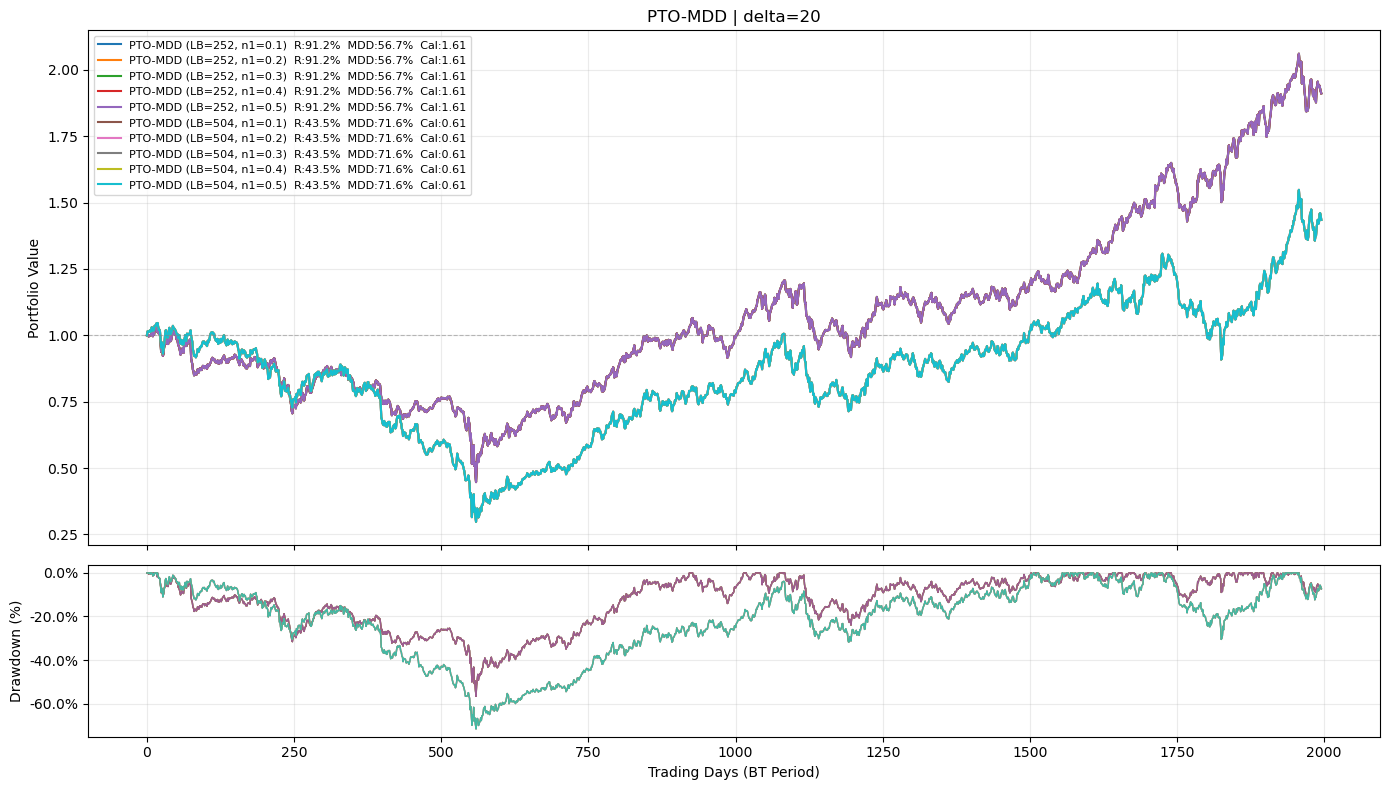

PTO-MDD: 100%|████████| 10/10 [09:08<00:00, 54.81s/it, LB=504, delta=20, n1=0.5]


───────────────────────────────────────────────────────────────────────────
  Label                                 Ann.Ret   Ann.Vol       MDD   Calmar
───────────────────────────────────────────────────────────────────────────
  PTO-MDD (LB=252, n1=0.1)                8.53%    22.02%    56.66%     0.15
  PTO-MDD (LB=252, n1=0.2)                8.53%    22.02%    56.66%     0.15
  PTO-MDD (LB=252, n1=0.3)                8.53%    22.02%    56.66%     0.15
  PTO-MDD (LB=252, n1=0.4)                8.53%    22.02%    56.66%     0.15
  PTO-MDD (LB=252, n1=0.5)                8.53%    22.02%    56.66%     0.15
  PTO-MDD (LB=504, n1=0.1)                4.67%    28.18%    71.60%     0.07
  PTO-MDD (LB=504, n1=0.2)                4.67%    28.18%    71.60%     0.07
  PTO-MDD (LB=504, n1=0.3)                4.67%    28.18%    71.60%     0.07
  PTO-MDD (LB=504, n1=0.4)                4.67%    28.18%    71.60%     0.07
  PTO-MDD (LB=504, n1=0.5)                4.67%    28.18%    71.60%     0.07


In [35]:
import importlib
from tqdm.auto import tqdm

import pto_mdd
importlib.reload(pto_mdd)
from pto_mdd import train_pto_mdd, backtest_pto_mdd

total = len(DELTA_LIST) * len(configs)
pbar  = tqdm(total=total, desc="PTO-MDD", ncols=80)

for delta_val in DELTA_LIST:
    all_results_pto_mdd = []

    for cfg in configs:
        LOOKBACK = cfg["LOOKBACK"]
        n1       = cfg["n1"]

        pbar.set_postfix(delta=delta_val, LB=LOOKBACK, n1=n1)

        INPUT_DIM = LOOKBACK * N_STOCKS

        train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                     start=LOOKBACK, end=N_TRAIN)
        val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                     start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
        rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                     start=BT_START_IDX, end=BT_START_IDX + N_BT)
        rebal_samples = rebal_samples[::HORIZON]

        torch.manual_seed(42)

        model_pto_mdd = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
        train_pto_mdd(model_pto_mdd, train_samples, val_samples,
                      EPOCHS, BATCH_SIZE, LR, patience=PATIENCE)

        bt_pto_mdd = backtest_pto_mdd(
            model_pto_mdd, rebal_samples, N, d, C,
            n1=n1, x_min=x_min, x_max=x_max, gamma=gamma,
            delta=delta_val,
            is_mean=is_mean, is_std=is_std,
            stock_names=stock_names,
        )
        all_results_pto_mdd.append((bt_pto_mdd, f"PTO-MDD (LB={LOOKBACK}, n1={n1})"))

        pbar.update(1)
        pbar.refresh()

    plot_multi_pnl(all_results_pto_mdd, title=f"PTO-MDD | delta={delta_val}")

pbar.close()


In [10]:
import importlib
from tqdm.auto import tqdm

import pto_mvo
importlib.reload(pto_mvo)
from pto_mvo import train_pto_mvo, backtest_pto_mvo

total = len(DELTA_LIST) * len(LOOKBACK_LIST)
pbar  = tqdm(total=total, desc="PTO-MVO", ncols=80)

for delta_val in DELTA_LIST:
    all_results_mvo = []

    for lookback in LOOKBACK_LIST:
        pbar.set_postfix(delta=delta_val, LB=lookback)

        INPUT_DIM = lookback * N_STOCKS

        train_samples = make_windows(full_np, lookback, HORIZON,
                                     start=lookback, end=N_TRAIN)
        val_samples   = make_windows(full_np, lookback, HORIZON,
                                     start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
        rebal_samples = make_windows(full_np, lookback, HORIZON,
                                     start=BT_START_IDX, end=BT_START_IDX + N_BT)
        rebal_samples = rebal_samples[::HORIZON]

        torch.manual_seed(42)

        model_pto_mvo = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
        train_pto_mvo(model_pto_mvo, train_samples, val_samples,
                      EPOCHS, BATCH_SIZE, LR, patience=PATIENCE)

        bt_pto_mvo = backtest_pto_mvo(
            model_pto_mvo, rebal_samples, N, d, C,
            delta=delta_val,
            x_min=x_min, x_max=x_max, gamma=gamma,
            is_mean=is_mean, is_std=is_std,
            stock_names=stock_names,
        )
        all_results_mvo.append((bt_pto_mvo, f"PTO-MVO (LB={lookback})"))

        pbar.update(1)
        pbar.refresh()

    plot_multi_pnl(all_results_mvo, title=f"PTO-MVO | delta={delta_val}")

pbar.close()


PTO-MVO:   0%|                          | 0/2 [00:33<?, ?it/s, LB=252, delta=20]


NameError: name 'PredictionModel' is not defined